# 📊 Statistical Trading Framework v2.0: Data Exploration
This notebook validates the **Layer 1 (Data Loader)** and **Layer 3 (Regime Detection)** components of the new framework while enforcing **ADR-002 (%-normalization)** and **ADR-004 (Institutional Windows)**.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure project root is in path (3 levels up from research folder)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../../"))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from scripts.trading_framework.data.loader import FrameworkLoader
from scripts.trading_framework.regime.regime_models import ThresholdRegimeModel

# 2. Load Fused Data (2006-Present)
loader = FrameworkLoader(ticker="NQ1")
df = loader.load(include_historical=True)

print(f"Loaded {len(df):,} bars of NQ data.")
print(f"Range: {df.index.min()} to {df.index.max()}")
df.head()

  [Live Storage] Loaded 433465 rows from live_storage_-NQ.parquet
  [Historical]   Loaded 6343621 rows from NQ1_1m.parquet
  [Fused]        Total: 6402708 rows | Range: 2006-01-05 13:58:00 to 2026-03-27 20:59:00
Loaded 59,087 bars of NQ data.
Range: 2026-01-25 23:00:00 to 2026-03-27 20:59:00


,time,open,high,low,close,volume,timestamp,returns,log_returns,range_pct,gap_pct
datetime,,,,,,,,,,,
2026-01-25 23:00:00,1.769382e+12,25585.50,25585.50,25365.25,25475.00,1526,2026-01-25 23:00:00,-0.008002,-0.008034,0.008577,-0.003699
2026-01-25 23:01:00,1.769382e+12,25478.50,25481.25,25425.25,25466.00,653,2026-01-25 23:01:00,-0.000353,-0.000353,0.002198,0.000137
2026-01-25 23:02:00,1.769382e+12,25463.00,25491.25,25442.00,25465.00,366,2026-01-25 23:02:00,-0.000039,-0.000039,0.001934,-0.000118
2026-01-25 23:03:00,1.769382e+12,25458.25,25468.50,25449.75,25453.25,245,2026-01-25 23:03:00,-0.000461,-0.000462,0.000736,-0.000265
2026-01-25 23:04:00,1.769382e+12,25453.00,25468.25,25448.00,25462.50,200,2026-01-25 23:04:00,0.000363,0.000363,0.000796,-0.000010


### 3. Verify ADR-002: Statistical Normalization
We check if the stationary features (returns, log_returns, range_pct) are correctly populated.

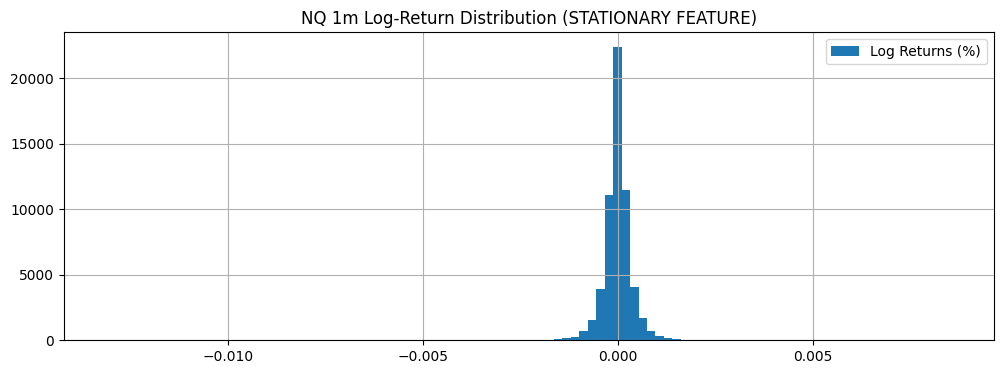

In [2]:
plt.figure(figsize=(12, 4))
df['log_returns'].hist(bins=100, label="Log Returns (%)")
plt.title("NQ 1m Log-Return Distribution (STATIONARY FEATURE)")
plt.legend()
plt.show()

### 4. Regime Analysis (Threshold Volatility)
Identify periods of High vs. Low Volatility to inform signal generation.

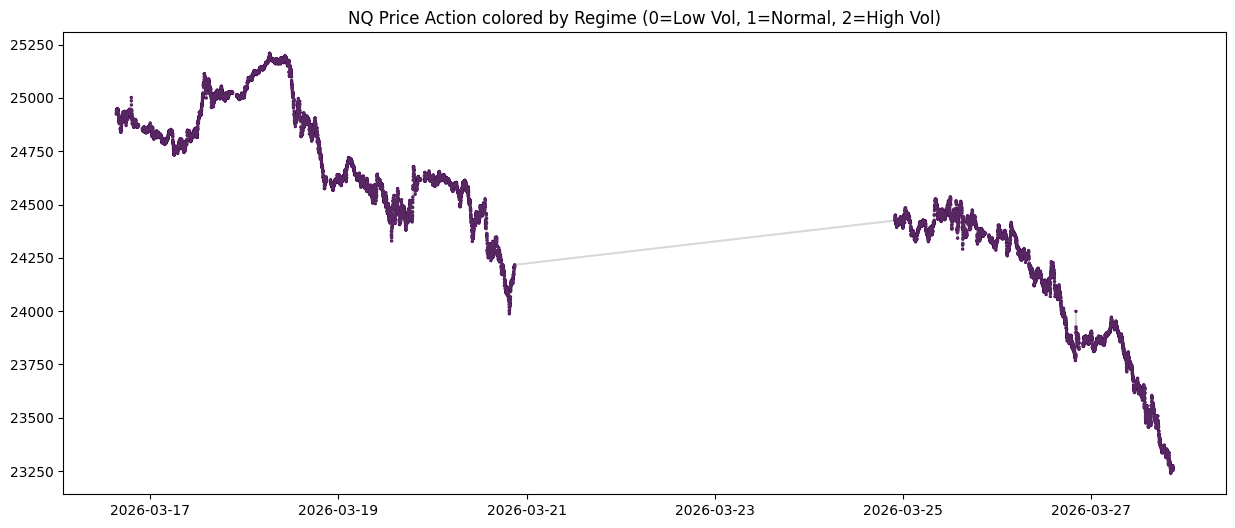

In [3]:
regime_model = ThresholdRegimeModel()
df['regime'] = regime_model.predict_regime(df)

plt.figure(figsize=(15, 6))
plt.plot(df.index[-10000:], df['close'][-10000:], color='gray', alpha=0.3)
plt.scatter(df.index[-10000:], df['close'][-10000:], c=df['regime'][-10000:], cmap='viridis', s=2)
plt.title("NQ Price Action colored by Regime (0=Low Vol, 1=Normal, 2=High Vol)")
plt.show()